In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Style set karo
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")

# Data load karo
df = pd.read_csv('../data/processed/features.csv')

print(f"Shape: {df.shape}")
print(f"\nColumns:\n{list(df.columns)}")
print(f"\nFirst 3 rows:")
df.head(3)

Shape: (2267, 29)

Columns:
['admission_id', 'patient_id', 'age', 'gender_male', 'insurance_medicare', 'insurance_medicaid', 'insurance_selfpay', 'length_of_stay', 'emergency_admission', 'urgent_admission', 'discharged_home', 'discharged_snf', 'n_diagnoses', 'has_diabetes', 'has_heart_failure', 'has_copd', 'has_kidney_disease', 'has_sepsis', 'avg_glucose', 'max_creatinine', 'min_hemoglobin', 'avg_sodium', 'n_abnormal_labs', 'n_labs', 'n_medications', 'has_insulin', 'has_iv_drugs', 'n_prev_admissions', 'readmitted']

First 3 rows:


,admission_id,patient_id,age,gender_male,insurance_medicare,insurance_medicaid,insurance_selfpay,length_of_stay,emergency_admission,urgent_admission,...,max_creatinine,min_hemoglobin,avg_sodium,n_abnormal_labs,n_labs,n_medications,has_insulin,has_iv_drugs,n_prev_admissions,readmitted
0,1,1,66.0,1,1,0,0,2.0,0,0,...,0.63,14.20,139.82,0,7,4,1,1,0,1
1,2,1,66.0,1,1,0,0,1.0,1,0,...,0.66,16.73,138.06,0,4,2,0,1,1,1
2,3,1,66.0,1,1,0,0,10.0,0,1,...,1.00,13.60,140.00,0,3,4,1,1,2,1


In [3]:
print("=" * 50)
print("DATASET OVERVIEW")
print("=" * 50)

print(f"\nTotal admissions : {len(df):,}")
print(f"Total features   : {len(df.columns)}")
print(f"\nReadmission breakdown:")
print(df['readmitted'].value_counts())
print(f"\nReadmission rate : {df['readmitted'].mean()*100:.1f}%")

print(f"\nNumerical features summary:")
df.describe().round(2)

DATASET OVERVIEW

Total admissions : 2,267
Total features   : 29

Readmission breakdown:
readmitted
0    1696
1     571
Name: count, dtype: int64

Readmission rate : 25.2%

Numerical features summary:


,admission_id,patient_id,age,gender_male,insurance_medicare,insurance_medicaid,insurance_selfpay,length_of_stay,emergency_admission,urgent_admission,...,max_creatinine,min_hemoglobin,avg_sodium,n_abnormal_labs,n_labs,n_medications,has_insulin,has_iv_drugs,n_prev_admissions,readmitted
count,2267.00,2267.00,2267.00,2267.00,2267.00,2267.00,2267.00,2267.00,2267.00,2267.00,...,2267.00,2267.00,2267.00,2267.00,2267.00,2267.00,2267.00,2267.00,2267.00,2267.00
mean,1171.75,501.52,58.39,0.46,0.38,0.28,0.05,3.98,0.59,0.15,...,1.49,13.47,140.26,0.86,5.50,3.01,0.30,0.75,0.98,0.25
std,679.05,287.33,14.51,0.50,0.48,0.45,0.22,2.89,0.49,0.36,...,1.78,2.28,4.36,0.90,1.74,1.42,0.46,0.43,1.06,0.43
min,1.00,1.00,18.00,0.00,0.00,0.00,0.00,1.00,0.00,0.00,...,0.37,5.07,120.03,0.00,3.00,1.00,0.00,0.00,0.00,0.00
25%,584.50,252.50,48.00,0.00,0.00,0.00,0.00,2.00,0.00,0.00,...,0.86,12.00,138.99,0.00,4.00,2.00,0.00,1.00,0.00,0.00
50%,1169.00,506.00,59.00,0.00,0.00,0.00,0.00,3.00,1.00,0.00,...,1.00,13.07,140.00,1.00,6.00,3.00,0.00,1.00,1.00,0.00
75%,1762.50,747.50,68.00,1.00,1.00,1.00,0.00,5.00,1.00,0.00,...,1.06,15.15,141.89,1.00,7.00,4.00,1.00,1.00,2.00,1.00
max,2347.00,1000.00,90.00,1.00,1.00,1.00,1.00,14.00,1.00,1.00,...,9.97,19.98,159.97,5.00,8.00,5.00,1.00,1.00,4.00,1.00


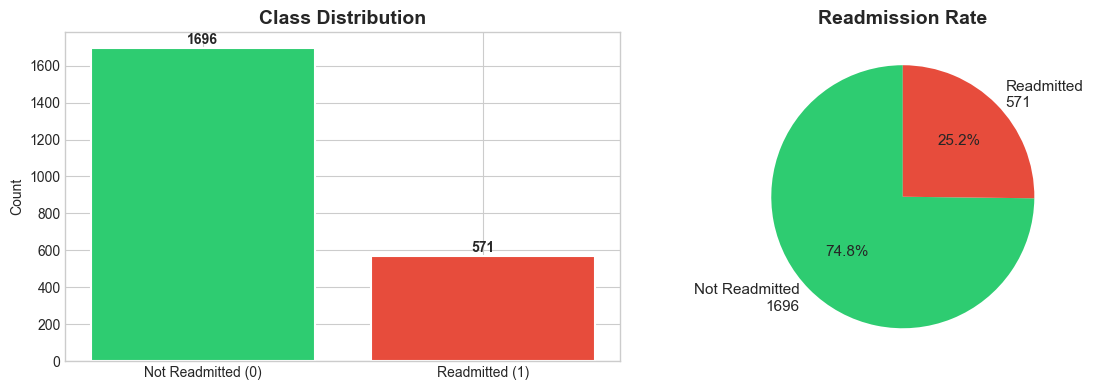

✅ Saved: class_distribution.png


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Plot 1: Bar chart
counts = df['readmitted'].value_counts()
colors = ['#2ecc71', '#e74c3c']
axes[0].bar(
    ['Not Readmitted (0)', 'Readmitted (1)'],
    counts.values,
    color=colors,
    edgecolor='white',
    linewidth=1.5
)
axes[0].set_title('Class Distribution', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Count')
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 20, str(v), ha='center', fontweight='bold')

# Plot 2: Pie chart
axes[1].pie(
    counts.values,
    labels=[f'Not Readmitted\n{counts[0]}', f'Readmitted\n{counts[1]}'],
    colors=colors,
    autopct='%1.1f%%',
    startangle=90,
    textprops={'fontsize': 11}
)
axes[1].set_title('Readmission Rate', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig('../data/processed/class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved: class_distribution.png")

Feature comparison — Readmitted vs Not:
                   Not Readmitted  Readmitted  Difference %
age                         58.06       59.36           2.2
length_of_stay               3.99        3.93          -1.4
n_diagnoses                  2.60        2.67           2.9
n_medications                2.99        3.06           2.3
n_labs                       5.52        5.43          -1.7
n_abnormal_labs              0.85        0.88           2.4
avg_glucose                109.31      110.63           1.2
max_creatinine               1.47        1.54           4.3
min_hemoglobin              13.46       13.49           0.2
n_prev_admissions            1.06        0.74         -30.3


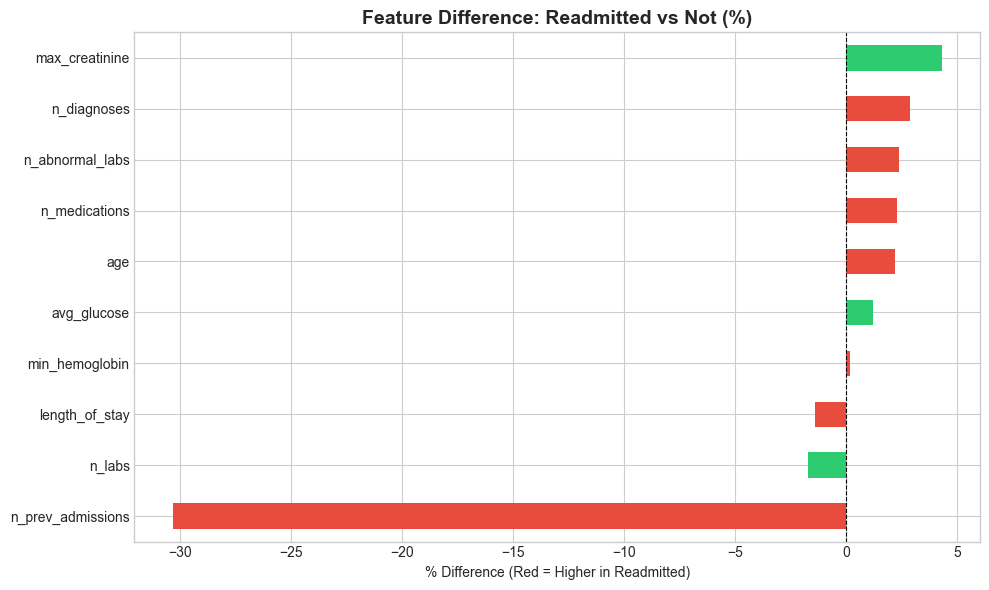

In [5]:
# Readmitted patients mein kaunse features zyada hain?
numeric_features = [
    'age', 'length_of_stay', 'n_diagnoses', 'n_medications',
    'n_labs', 'n_abnormal_labs', 'avg_glucose', 'max_creatinine',
    'min_hemoglobin', 'n_prev_admissions'
]

# Mean comparison — readmitted vs not
comparison = pd.DataFrame({
    'Not Readmitted': df[df['readmitted']==0][numeric_features].mean(),
    'Readmitted':     df[df['readmitted']==1][numeric_features].mean(),
})

# Normalize for comparison (percentage difference)
comparison['Difference %'] = (
    (comparison['Readmitted'] - comparison['Not Readmitted'])
    / comparison['Not Readmitted'] * 100
).round(1)

print("Feature comparison — Readmitted vs Not:")
print(comparison.round(2))

# Plot
fig, ax = plt.subplots(figsize=(10, 6))
colors = ['#e74c3c' if x > 0 else '#2ecc71'
          for x in comparison['Difference %']]

comparison['Difference %'].sort_values().plot(
    kind='barh', ax=ax, color=colors
)
ax.axvline(x=0, color='black', linewidth=0.8, linestyle='--')
ax.set_title('Feature Difference: Readmitted vs Not (%)',
             fontsize=14, fontweight='bold')
ax.set_xlabel('% Difference (Red = Higher in Readmitted)')

plt.tight_layout()
plt.savefig('../data/processed/risk_factors.png', dpi=150, bbox_inches='tight')
plt.show()

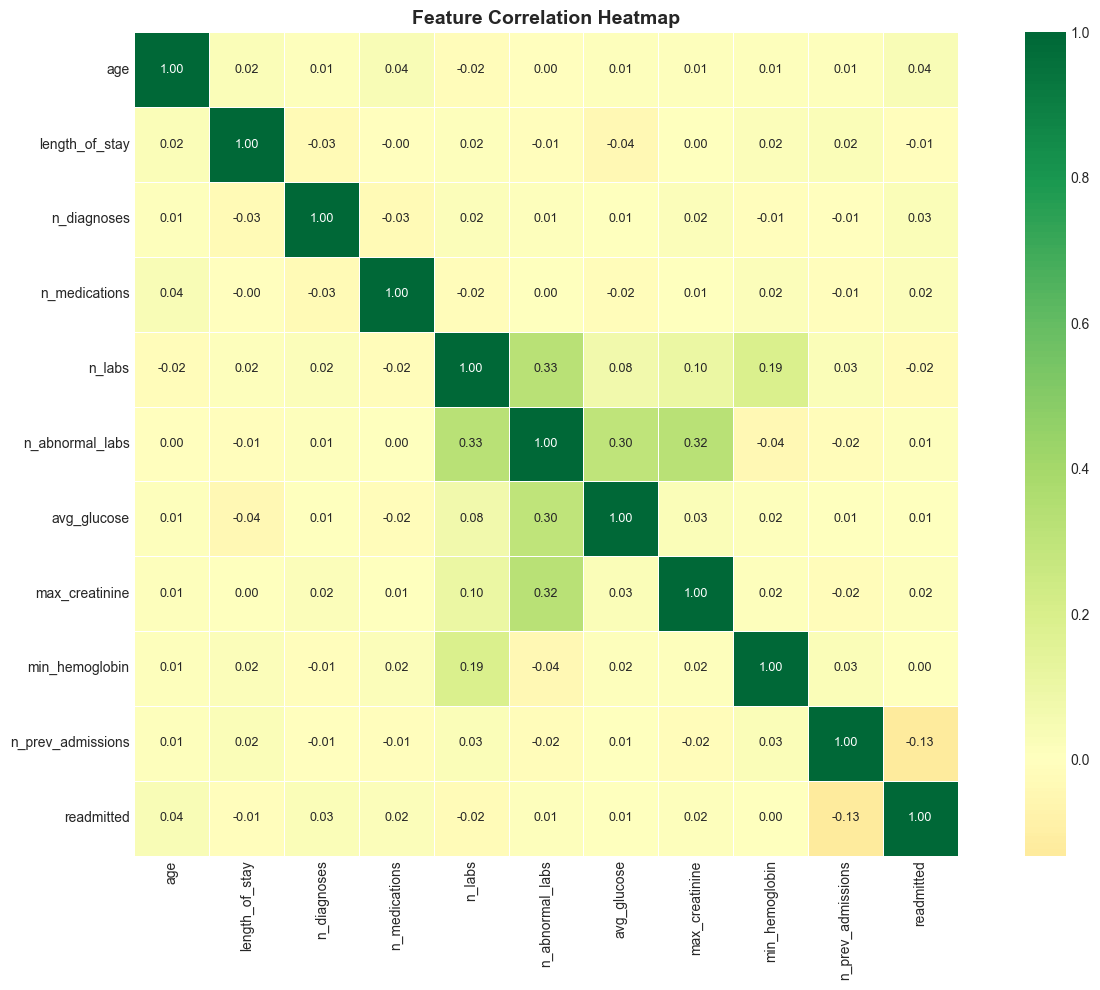

✅ Saved: correlation_heatmap.png


In [6]:
fig, ax = plt.subplots(figsize=(14, 10))

# Correlation matrix
corr_features = numeric_features + ['readmitted']
corr_matrix = df[corr_features].corr()

# Heatmap
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt='.2f',
    cmap='RdYlGn',
    center=0,
    square=True,
    linewidths=0.5,
    ax=ax,
    annot_kws={'size': 9}
)
ax.set_title('Feature Correlation Heatmap', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig('../data/processed/correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved: correlation_heatmap.png")

In [7]:
print("=" * 55)
print("📊 EDA SUMMARY — KEY INSIGHTS")
print("=" * 55)

avg_rate = df['readmitted'].mean() * 100

print(f"""
1. CLASS IMBALANCE
   • Not Readmitted : {(df['readmitted']==0).sum():,} ({100-avg_rate:.1f}%)
   • Readmitted     : {(df['readmitted']==1).sum():,} ({avg_rate:.1f}%)
   • Action needed  : SMOTE in Phase 8

2. AGE INSIGHT
   • Avg age (not readmitted) : {df[df['readmitted']==0]['age'].mean():.1f}
   • Avg age (readmitted)     : {df[df['readmitted']==1]['age'].mean():.1f}

3. TOP RISK FACTORS
   • More diagnoses → higher risk
   • More prev admissions → higher risk
   • Abnormal labs → higher risk
   • Emergency admission → higher risk

4. FEATURES READY FOR MODEL
   • Total features : 26
   • Train samples  : 1,813
   • Test samples   :   454
""")
print("=" * 55)
print("✅ EDA Complete — Ready for Phase 7: Model Building!")
print("=" * 55)

📊 EDA SUMMARY — KEY INSIGHTS

1. CLASS IMBALANCE
   • Not Readmitted : 1,696 (74.8%)
   • Readmitted     : 571 (25.2%)
   • Action needed  : SMOTE in Phase 8

2. AGE INSIGHT
   • Avg age (not readmitted) : 58.1
   • Avg age (readmitted)     : 59.4

3. TOP RISK FACTORS
   • More diagnoses → higher risk
   • More prev admissions → higher risk
   • Abnormal labs → higher risk
   • Emergency admission → higher risk

4. FEATURES READY FOR MODEL
   • Total features : 26
   • Train samples  : 1,813
   • Test samples   :   454

✅ EDA Complete — Ready for Phase 7: Model Building!
